In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/BMW sales data (2010-2024).csv')

In [ ]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [ ]:
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [ ]:
df.shape

(50000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [ ]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Model,0
Year,0
Region,0
Color,0
Fuel_Type,0
Transmission,0
Engine_Size_L,0
Mileage_KM,0
Price_USD,0
Sales_Volume,0


<Axes: >

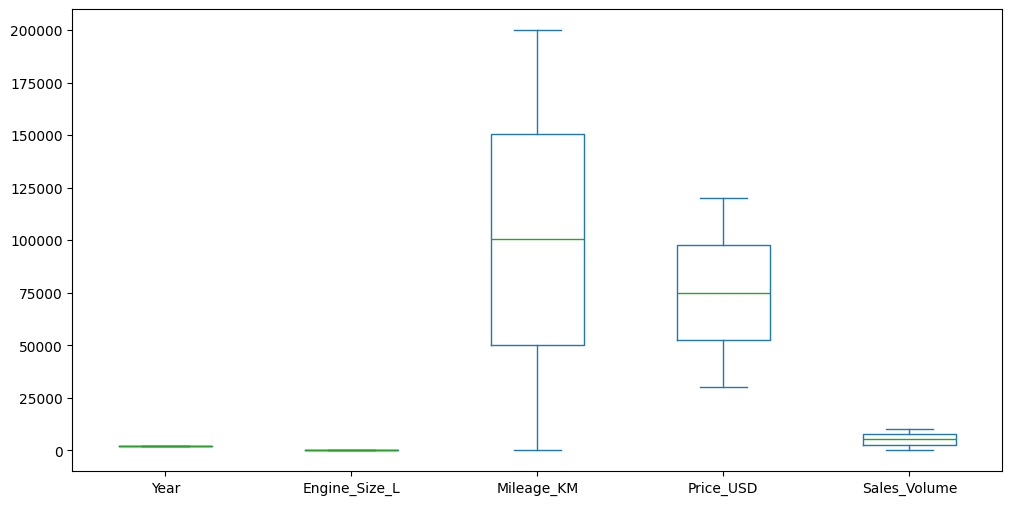

In [ ]:
df[['Year','Engine_Size_L','Mileage_KM','Price_USD','Sales_Volume']].plot(kind='box',figsize=(12,6))

In [ ]:
cols=['Year','Engine_Size_L','Mileage_KM','Price_USD','Sales_Volume']
for col in cols:
   q1=df[col].quantile(0.25)
   q3=df[col].quantile(0.75)
   IQR=q3-q1
   lower=q1-1.5*IQR
   upper=q3+1.5*IQR
   outliers=((df[col]<lower)|(df[col]>upper)).sum()
   print(col ," : ",outliers)

Year  :  0
Engine_Size_L  :  0
Mileage_KM  :  0
Price_USD  :  0
Sales_Volume  :  0


In [ ]:
total_units_sold = df['Sales_Volume'].sum()
print("Total Units Sold:", total_units_sold)

Total Units Sold: 253375734


In [ ]:
average_price = df['Price_USD'].mean()
print("Average Price:", average_price)

Average Price: 75034.6009


In [ ]:
average_sales_volume = df['Sales_Volume'].mean()
print("Average Sales Volume:", average_sales_volume)

Average Sales Volume: 5067.51468


In [ ]:
average_mileage = df['Mileage_KM'].mean()
print("Average Mileage:", average_mileage)

Average Mileage: 100307.20314


In [ ]:
unique_models = df['Model'].nunique()
print("Number of Unique Models:", unique_models)

Number of Unique Models: 11


In [ ]:
df['Total_Revenue'] = df['Price_USD'] * df['Sales_Volume']
total_revenue = df['Total_Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 19012242534459


In [ ]:
region_revenue = (
    df.groupby('Region')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Revenue')
)

region_revenue

,Total Revenue
Region,
Asia,3250635961348
Europe,3188079573212
North America,3182938635076
Middle East,3167783530851
South America,3113805414620
Africa,3108999419352


In [ ]:
year_revenue = (
    df.groupby('Year')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Revenue')
)

year_revenue.head(5)

,Total Revenue
Year,
2022,1344427738820
2024,1312808115466
2019,1289342744664
2016,1284641854435
2021,1272402559079


In [ ]:
color_revenue = (
    df.groupby('Color')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Revenue')
)

color_revenue.head(5)

,Total Revenue
Color,
Red,3205175199705
Silver,3187790756472
White,3187478386188
Blue,3177753211463
Grey,3133799363675


In [ ]:
fuel_revenue = (
    df.groupby('Fuel_Type')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Revenue')
)

fuel_revenue

,Total Revenue
Fuel_Type,
Hybrid,4820671669300
Petrol,4756136615908
Electric,4750735161530
Diesel,4684699087721


In [ ]:
transmission_revenue = (
    df.groupby('Transmission')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Revenue')
)

transmission_revenue

,Total Revenue
Transmission,
Manual,9551663067045
Automatic,9460579467414


In [ ]:
model_mileage = (
    df.groupby('Model')['Mileage_KM']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Mileage')
)

model_mileage

,Total Mileage
Model,
7 Series,470296246
5 Series,465429666
3 Series,460234733
X1,458716867
M5,458291935
i8,458054655
i3,455957150
X3,452923760
X5,449865453


In [ ]:
model_sales = (
    df.groupby('Model')['Sales_Volume']
      .sum()
      .sort_values(ascending=False)
      .to_frame('Total Quantity Sold')
)

model_sales.head(5)

,Total Quantity Sold
Model,
7 Series,23786466
i8,23423891
X1,23406060
3 Series,23281303
i3,23133849


In [ ]:
model_analysis = (
    df.groupby('Model')
      .agg(
          Total_Sales=('Sales_Volume', 'sum'),
          Average_Price=('Price_USD', 'mean'),
          Average_Mileage=('Mileage_KM', 'mean'),
          Total_Revenue=('Total_Revenue', 'sum')
      )
      .sort_values('Total_Revenue', ascending=False)
)

model_analysis.head(10)

,Total_Sales,Average_Price,Average_Mileage,Total_Revenue
Model,,,,
7 Series,23786466,75570.196742,100792.165881,1790070249282
3 Series,23281303,75566.233950,100159.898368,1768534028214
i8,23423891,75366.270951,99447.384933,1764743448529
X1,23406060,75262.219037,100375.682057,1752985285361
5 Series,23097519,75287.844077,101356.634582,1735712423092
i3,23133849,74800.268081,98734.766133,1724197530210
X5,22709749,74708.116782,100259.739915,1708653383772
X3,22745529,75016.616856,100716.869024,1707951188482
M5,22779688,74474.930996,102342.995757,1698467355916


In [ ]:
sales_classification_count = df['Sales_Classification'].value_counts()
print(sales_classification_count)

Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64


In [ ]:
classification_revenue = (
    df.groupby('Sales_Classification')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

classification_revenue

,Total_Revenue
Sales_Classification,
High,9710814216536
Low,9301428317923


In [ ]:
classification_sales = (
    df.groupby('Sales_Classification')['Sales_Volume']
      .mean()
      .sort_values(ascending=False)
)

classification_sales

,Sales_Volume
Sales_Classification,
High,8497.496327
Low,3562.838954


In [ ]:
yearly_revenue = (
    df.groupby('Year')['Total_Revenue']
      .sum()
      .sort_index()
)

yearly_revenue

,Total_Revenue
Year,
2010,1261631480830
2011,1258944308614
2012,1257840248199
2013,1258599026870
2014,1269989867142
2015,1255056528796
2016,1284641854435
2017,1251237076544
2018,1244465589591


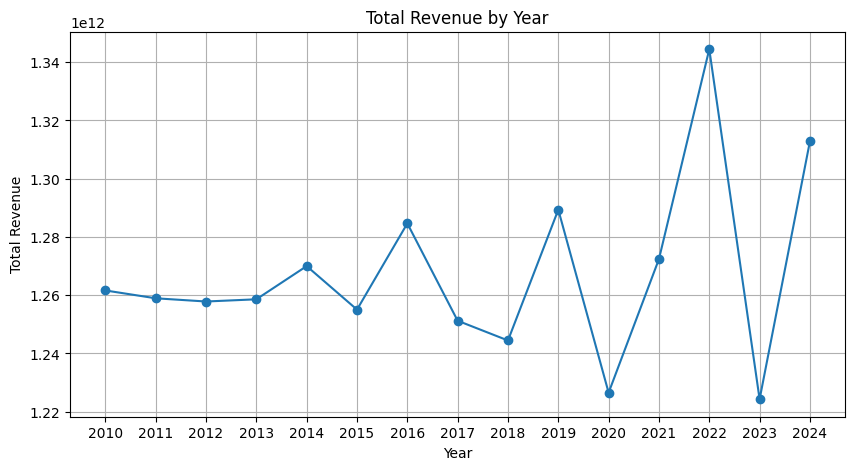

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_revenue.index,
    yearly_revenue.values,
    marker='o'
)

plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')

plt.xticks(yearly_revenue.index)
plt.grid(True)

plt.show()

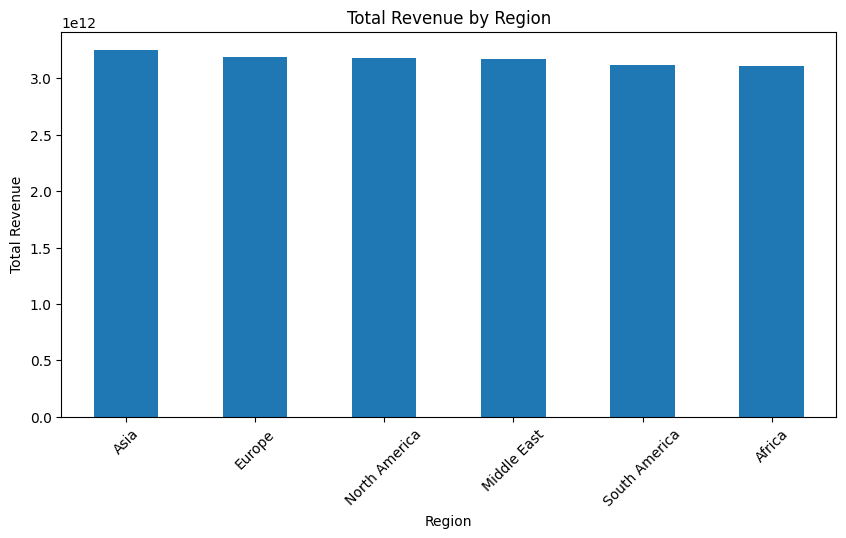

In [ ]:
region_revenue = (
    df.groupby('Region')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

region_revenue.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

plt.show()

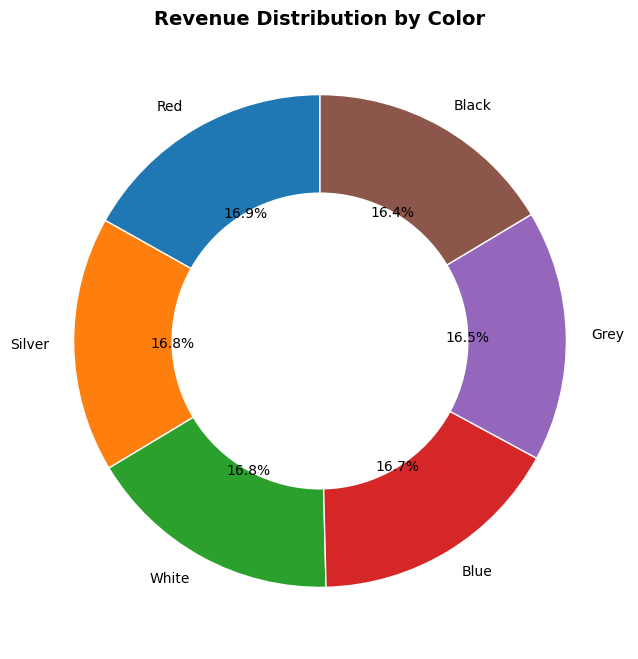

In [ ]:
color_revenue = (
    df.groupby('Color')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

plt.pie(
    color_revenue.values,
    labels=color_revenue.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(
        width=0.4,
        edgecolor='white'
    )
)

plt.title(
    'Revenue Distribution by Color',
    fontsize=14,
    fontweight='bold'
)

plt.show()

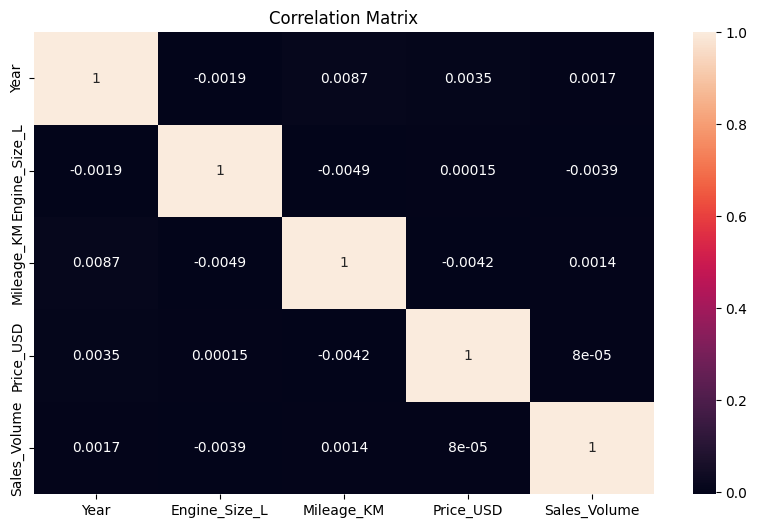

In [ ]:
correlation_matrix = df[
    [
        'Year',
        'Engine_Size_L',
        'Mileage_KM',
        'Price_USD',
        'Sales_Volume'
    ]
].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title('Correlation Matrix')

plt.show()

In [ ]:
from google.colab import files
files.download('/content/final_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>